In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import files
uploaded=files.upload()

Saving kaggle (2).json to kaggle (2).json


In [3]:
!mv "kaggle (2).json" kaggle.json

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle --version

Kaggle CLI 2.0.2


In [6]:
!kaggle datasets list -s mammography

ref                                                             title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
kmader/mias-mammography                                         MIAS Mammography                                      326653075  2017-11-01 10:50:49.467000          24003        260  0.75             
skooch/ddsm-mammography                                         DDSM Mammography                                     3093452937  2018-07-03 08:38:28.307000          11243        193  0.75             
ahmadihossein/csaw-cc-mammography                               CSAW-CC (mammography)                                   2171727  2024-11-25 06:55:19.553000            434         25  1            

In [7]:
!pip install -q kaggle

In [8]:
!kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset

Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
100% 4.95G/4.95G [04:49<00:00, 18.4MB/s]



In [9]:
!ls

cbis-ddsm-breast-cancer-image-dataset.zip  kaggle.json	sample_data


In [10]:
!find /content/ddsm | head -30

find: ‘/content/ddsm’: No such file or directory


In [11]:
import os

for root, dirs, files in os.walk('/content/ddsm'):
    print(root)
    print("Folders:", dirs)
    print("Files:", files[:5])
    print("-"*50)

In [12]:
!unzip -q cbis-ddsm-breast-cancer-image-dataset.zip -d /content/ddsm

In [13]:
!ls /content

cbis-ddsm-breast-cancer-image-dataset.zip  ddsm  kaggle.json  sample_data


In [14]:
!find /content/ddsm | head -50

/content/ddsm
/content/ddsm/csv
/content/ddsm/csv/dicom_info.csv
/content/ddsm/csv/mass_case_description_test_set.csv
/content/ddsm/csv/mass_case_description_train_set.csv
/content/ddsm/csv/calc_case_description_train_set.csv
/content/ddsm/csv/meta.csv
/content/ddsm/csv/calc_case_description_test_set.csv
/content/ddsm/jpeg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.336294562711133796734275132653265929945
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.336294562711133796734275132653265929945/1-052.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.65293480911198171827402456830091994445
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.65293480911198171827402456830091994445/2-209.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.65293480911198171827402456830091994445/1-282.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.70058892510431415541436145992393610950
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.70058892510431415541436145992393610950/1-058.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.70058892

In [15]:
import os

image_paths = []

for root, dirs, files in os.walk('/content/ddsm/jpeg'):
    for file in files:
        if file.endswith('.jpg'):
            image_paths.append(os.path.join(root, file))

print("Total mammograms:", len(image_paths))

Total mammograms: 10237


In [16]:
from PIL import Image
sizes = []

for path in image_paths:
    img = Image.open(path)
    sizes.append(img.size)

import pandas as pd

size_df = pd.DataFrame(
    sizes,
    columns=['Width', 'Height']
)

size_df.describe()

,Width,Height
count,10237.000000,10237.000000
mean,2179.893328,3549.778841
std,1374.221082,2363.196643
min,68.000000,73.000000
25%,453.000000,441.000000
50%,2728.000000,4624.000000
75%,3112.000000,5476.000000
max,5431.000000,7111.000000


In [17]:
import glob

csv_files = glob.glob('/content/ddsm/**/*.csv', recursive=True)
print(csv_files)

['/content/ddsm/csv/dicom_info.csv', '/content/ddsm/csv/mass_case_description_test_set.csv', '/content/ddsm/csv/mass_case_description_train_set.csv', '/content/ddsm/csv/calc_case_description_train_set.csv', '/content/ddsm/csv/meta.csv', '/content/ddsm/csv/calc_case_description_test_set.csv']


In [18]:
import pandas as pd

dfs = []

for file in csv_files:
    try:
        df = pd.read_csv(file)
        dfs.append(df)
    except:
        pass

data = pd.concat(dfs, ignore_index=True)
data.head()

,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,subtlety,image file path,cropped image file path,ROI mask file path,breast density,calc type,calc distribution,Collection,Visibility,ImageCount
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16.0,16.0,BREAST,351.0,20160426.0,131732.685,WSD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16.0,16.0,BREAST,3526.0,20160426.0,143829.101,WSD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16.0,16.0,BREAST,1546.0,20160503.0,111956.298,WSD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16.0,16.0,BREAST,97.0,20160503.0,115347.770,WSD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8.0,8.0,Left Breast,3104.0,20160503.0,115347.770,WSD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
for p in image_paths[:30]:
    print(os.path.basename(p))

1-052.jpg
2-209.jpg
1-282.jpg
1-058.jpg
2-299.jpg
1-066.jpg
2-112.jpg
1-111.jpg
1-158.jpg
2-266.jpg
1-043.jpg
2-018.jpg
1-220.jpg
2-265.jpg
1-266.jpg
1-116.jpg
1-296.jpg
1-066.jpg
1-036.jpg
2-193.jpg
1-192.jpg
2-242.jpg
1-070.jpg
1-162.jpg
2-140.jpg
1-253.jpg
1-108.jpg
2-034.jpg
1-033.jpg
1-079.jpg


In [20]:
for p in image_paths[:20]:
    print(p)

/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.336294562711133796734275132653265929945/1-052.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.65293480911198171827402456830091994445/2-209.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.65293480911198171827402456830091994445/1-282.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.70058892510431415541436145992393610950/1-058.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.70058892510431415541436145992393610950/2-299.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.52915627412340525122930510274096143514/1-066.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.326342684212605282109324509633061180980/2-112.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.326342684212605282109324509633061180980/1-111.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.354465341311462662536122889121674320216/1-158.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.354465341311462662536122889121674320216/2-266.jpg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.732527079123411025084

In [22]:
import pandas as pd

df = pd.read_csv('/content/dicom_info.csv')

In [23]:
df['SeriesDescription'].value_counts()

,count
SeriesDescription,
cropped images,3567
ROI mask images,3247
full mammogram images,2857


In [24]:
full_df = df[df['SeriesDescription'] == 'full mammogram images']
mask_df = df[df['SeriesDescription'] == 'ROI mask images']
crop_df = df[df['SeriesDescription'] == 'cropped images']

print("Full mammograms:", len(full_df))
print("Masks:", len(mask_df))
print("Cropped:", len(crop_df))

Full mammograms: 2857
Masks: 3247
Cropped: 3567


In [25]:
print(df.columns)

Index(['file_path', 'image_path', 'AccessionNumber', 'BitsAllocated',
       'BitsStored', 'BodyPartExamined', 'Columns', 'ContentDate',
       'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber',
       'LargestImagePixelValue', 'Laterality', 'Modality', 'PatientBirthDate',
       'PatientID', 'PatientName', 'PatientOrientation', 'PatientSex',
       'PhotometricInterpretation', 'PixelRepresentation',
       'ReferringPhysicianName', 'Rows', 'SOPClassUID', 'SOPInstanceUID',
       'SamplesPerPixel', 'SecondaryCaptureDeviceManufacturer',
       'SecondaryCaptureDeviceManufacturerModelName', 'SeriesDescription',
       'SeriesInstanceUID', 'SeriesNumber', 'SmallestImagePixelValue',
       'SpecificCharacterSet', 'StudyDate', 'StudyID', 'StudyInstanceUID',
       'StudyTime'],
      dtype='object')


In [26]:
df['SeriesDescription'].value_counts()

,count
SeriesDescription,
cropped images,3567
ROI mask images,3247
full mammogram images,2857


In [27]:
patient = df['PatientID'].iloc[0]

df[df['PatientID'] == patient][
    ['PatientID',
     'SeriesDescription',
     'image_path',
     'StudyInstanceUID',
     'SeriesInstanceUID']
]

,PatientID,SeriesDescription,image_path,StudyInstanceUID,SeriesInstanceUID
0,Mass-Training_P_01265_RIGHT_MLO_1,cropped images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...
4677,Mass-Training_P_01265_RIGHT_MLO_1,ROI mask images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153292...,1.3.6.1.4.1.9590.100.1.2.278094251111384326418...,1.3.6.1.4.1.9590.100.1.2.153292899210265727229...


In [28]:
df.groupby(
    ['PatientID', 'SeriesDescription']
).size().unstack(fill_value=0).head(20)

SeriesDescription,ROI mask images,cropped images,full mammogram images
PatientID,,,
Calc-Test_P_00038_LEFT_CC_1,0,1,0
Calc-Test_P_00038_LEFT_MLO_1,0,1,0
Calc-Test_P_00038_RIGHT_CC_1,0,1,0
Calc-Test_P_00038_RIGHT_CC_2,0,1,0
Calc-Test_P_00038_RIGHT_MLO_1,0,1,0
Calc-Test_P_00038_RIGHT_MLO_2,0,1,0
Calc-Test_P_00041_LEFT_CC_2,0,1,0
Calc-Test_P_00041_LEFT_MLO_2,0,1,0
Calc-Test_P_00077_LEFT_CC_1,0,1,0


In [29]:
df[['SeriesDescription', 'image_path']].head(10)

,SeriesDescription,image_path
0,cropped images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...
1,full mammogram images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...
2,full mammogram images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...
3,cropped images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...
4,NaN,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...
5,ROI mask images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339...
6,cropped images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339...
7,cropped images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.178994...
8,ROI mask images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.178994...
9,ROI mask images,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.411833...


In [30]:
df = df.dropna(subset=['SeriesDescription']).copy()

In [31]:
mammo_df = df[df['SeriesDescription'] == 'full mammogram images']
mask_df = df[df['SeriesDescription'] == 'ROI mask images']
crop_df = df[df['SeriesDescription'] == 'cropped images']

print(len(mammo_df))
print(len(mask_df))
print(len(crop_df))

2857
3247
3567


In [32]:
import os

df['exists'] = df['image_path'].apply(os.path.exists)

df['exists'].value_counts()

,count
exists,
False,9671


In [33]:
print(df['image_path'].iloc[0])

CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304/1-172.jpg


In [34]:
!ls /content
!find /content -type d | head -20

calc_case_description_test_set.csv	   kaggle.json
calc_case_description_train_set.csv	   mass_case_description_test_set.csv
cbis-ddsm-breast-cancer-image-dataset.zip  mass_case_description_train_set.csv
ddsm					   meta.csv
dicom_info.csv				   sample_data
/content
/content/.config
/content/.config/configurations
/content/.config/logs
/content/.config/logs/2026.06.04
/content/ddsm
/content/ddsm/csv
/content/ddsm/jpeg
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.336294562711133796734275132653265929945
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.65293480911198171827402456830091994445
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.70058892510431415541436145992393610950
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.52915627412340525122930510274096143514
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.326342684212605282109324509633061180980
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.354465341311462662536122889121674320216
/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.7325270791234110250842326163300534

In [35]:
import os

df['full_path'] = df['image_path'].str.replace(
    'CBIS-DDSM/jpeg',
    '/content/ddsm/jpeg',
    regex=False
)

df['exists'] = df['full_path'].apply(os.path.exists)

df['exists'].value_counts()

,count
exists,
True,9671


In [36]:
mammo_df = df[
    df['SeriesDescription'] == 'full mammogram images'
].copy()

mask_df = df[
    df['SeriesDescription'] == 'ROI mask images'
].copy()

print("Full mammograms:", len(mammo_df))
print("ROI masks:", len(mask_df))

Full mammograms: 2857
ROI masks: 3247


In [37]:
 df[df['PatientID'].str.contains('Mass-Training_P_01265', na=False)][
    ['PatientID',
     'SeriesDescription',
     'full_path']
]

,PatientID,SeriesDescription,full_path
0,Mass-Training_P_01265_RIGHT_MLO_1,cropped images,/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.12...
1771,Mass-Training_P_01265_RIGHT_CC,full mammogram images,/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.61...
4677,Mass-Training_P_01265_RIGHT_MLO_1,ROI mask images,/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.15...
4723,Mass-Training_P_01265_RIGHT_CC_1,ROI mask images,/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.16...
5067,Mass-Training_P_01265_RIGHT_CC_1,cropped images,/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.99...
7500,Mass-Training_P_01265_RIGHT_MLO,full mammogram images,/content/ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.25...


In [38]:
mammo_dict = {}

for _, row in mammo_df.iterrows():
    mammo_dict[row['PatientID']] = row['full_path']

In [39]:
pairs = []

for _, row in mask_df.iterrows():

    mask_id = row['PatientID']
    mask_path = row['full_path']

    # Remove _1, _2, ...
    base_id = mask_id.rsplit('_', 1)[0]

    if base_id in mammo_dict:
        pairs.append(
            (
                mammo_dict[base_id],
                mask_path
            )
        )

print("Total pairs:", len(pairs))

Total pairs: 3242


In [40]:
import os

print(os.path.exists(pairs[0][0]))
print(os.path.exists(pairs[0][1]))

True
True


In [41]:
from tqdm import tqdm
import cv2
import numpy as np

for i, (img_path, mask_path) in enumerate(tqdm(pairs)):

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if i == 0:
        print("Image:", img.shape, img.dtype)
        print("Mask :", mask.shape, mask.dtype)
        print("Mask unique:", np.unique(mask))

  0%|          | 1/3242 [00:00<12:14,  4.41it/s]

Image: (3931, 1981) uint8
Mask : (3931, 1981) uint8
Mask unique: [  0   1   2   3   4   5   6 249 250 251 252 253 254 255]


100%|██████████| 3242/3242 [04:04<00:00, 13.25it/s]


In [42]:
import cv2
import numpy as np

def orientation_fix(img, mask):
    """
    Make every mammogram look like:
           Breast on RIGHT
           Nipple pointing LEFT
    """

    binary = (img > 10).astype(np.uint8)

    left_pixels = binary[:, :img.shape[1]//2].sum()
    right_pixels = binary[:, img.shape[1]//2:].sum()

    # If breast is on LEFT, flip horizontally
    if left_pixels > right_pixels:
        img = cv2.flip(img, 1)
        mask = cv2.flip(mask, 1)

    return img, mask

In [43]:
img, mask = orientation_fix(img, mask)

if i == 0:
    print("After orientation:", img.shape, mask.shape)

In [44]:
def artifact_removal(img):
    """
    Remove labels/artifacts while preserving the breast.
    """

    _, binary = cv2.threshold(img, 10, 255, cv2.THRESH_BINARY)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary)

    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

    breast_mask = (labels == largest).astype(np.uint8)

    cleaned = img * breast_mask

    return cleaned

In [45]:
img = artifact_removal(img)

if i == 0:
    print("After artifact removal:", img.shape)
    print("Min:", img.min())
    print("Max:", img.max())

In [46]:
def clahe_enhancement(img):
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    return clahe.apply(img)

In [47]:
img = clahe_enhancement(img)

print("After CLAHE")
print("Min :", img.min())
print("Max :", img.max())

After CLAHE
Min : 2
Max : 255


In [48]:
from tqdm import tqdm
import cv2
import numpy as np

X = []
Y = []
tumor_areas = []

PAD = 40

for img_path, mask_path in tqdm(pairs):

    # Read
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        continue

    # Orientation
    img, mask = orientation_fix(img, mask)

    # Artifact Removal
    img = artifact_removal(img)

    # CLAHE
    img = clahe_enhancement(img)

    # Gaussian Blur
    img = cv2.GaussianBlur(img, (5,5), 0)

    # Resize
    img = cv2.resize(img, (512,512))
    mask = cv2.resize(mask, (512,512),
                      interpolation=cv2.INTER_NEAREST)

    # Binary Mask
    mask = (mask > 127).astype(np.uint8)

    # Tumor Area
    tumor_area = np.sum(mask)

    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        continue

    # Bounding Box
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    x1 = max(0, x1-PAD)
    y1 = max(0, y1-PAD)
    x2 = min(511, x2+PAD)
    y2 = min(511, y2+PAD)

    # ROI
    roi = img[y1:y2, x1:x2]
    roi_mask = mask[y1:y2, x1:x2]

    if roi.size == 0:
        continue

    # Resize ROI
    roi = cv2.resize(roi,(224,224))
    roi_mask = cv2.resize(
        roi_mask,
        (224,224),
        interpolation=cv2.INTER_NEAREST
    )

    # Binary Mask
    roi_mask = (roi_mask>0).astype(np.uint8)

    # Normalize
    roi = roi.astype(np.float32)/255.0

    X.append(roi)
    Y.append(roi_mask)
    tumor_areas.append(tumor_area)

X = np.array(X,dtype=np.float32)
Y = np.array(Y,dtype=np.uint8)
tumor_areas=np.array(tumor_areas)

print(X.shape)
print(Y.shape)
print(tumor_areas.shape)

100%|██████████| 3242/3242 [21:00<00:00,  2.57it/s]


(3242, 224, 224)
(3242, 224, 224)
(3242,)


In [49]:
np.save("roi_x.npy", X)
np.save("roi_y.npy", Y)
np.save("tumor_areas.npy", tumor_areas)

print("Saved Successfully")

Saved Successfully


In [50]:
import pandas as pd

area_df = pd.DataFrame({
    "Tumor Area": tumor_areas
})

print(area_df.describe())

          Tumor Area
count    3242.000000
mean     2415.897903
std      5878.158654
min        10.000000
25%       426.250000
50%       938.500000
75%      1978.250000
max    105595.000000


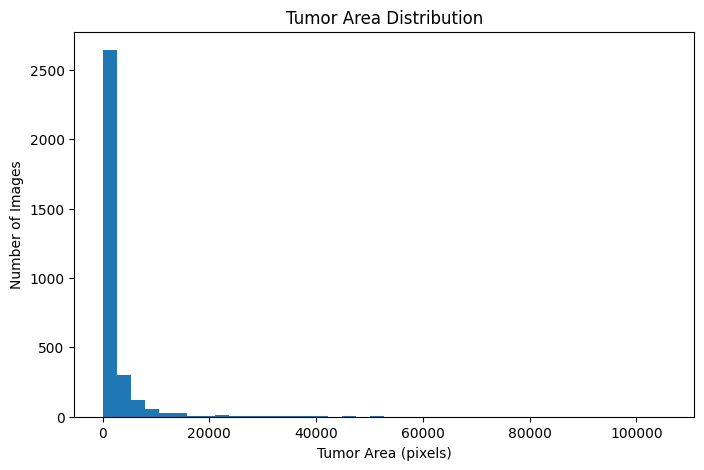

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(tumor_areas, bins=40)

plt.xlabel("Tumor Area (pixels)")
plt.ylabel("Number of Images")
plt.title("Tumor Area Distribution")

plt.show()

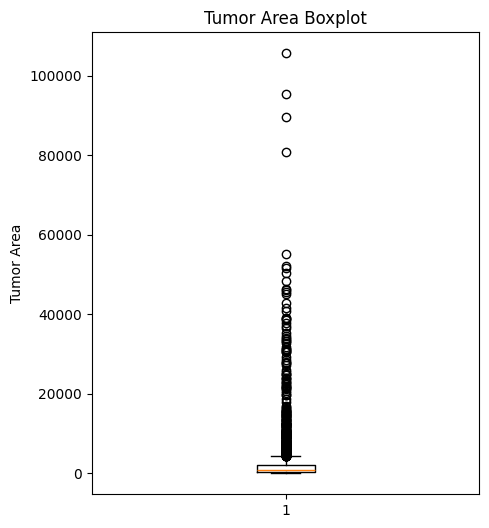

In [52]:
plt.figure(figsize=(5,6))

plt.boxplot(tumor_areas)

plt.ylabel("Tumor Area")

plt.title("Tumor Area Boxplot")

plt.show()

In [53]:
print("Minimum :", np.min(tumor_areas))
print("Maximum :", np.max(tumor_areas))
print("Mean    :", np.mean(tumor_areas))
print("Median  :", np.median(tumor_areas))
print("Std     :", np.std(tumor_areas))

print()

print("25% :", np.percentile(tumor_areas,25))
print("50% :", np.percentile(tumor_areas,50))
print("75% :", np.percentile(tumor_areas,75))

Minimum : 10
Maximum : 105595
Mean    : 2415.897902529303
Median  : 938.5
Std     : 5877.252020609522

25% : 426.25
50% : 938.5
75% : 1978.25


In [54]:
p20 = np.percentile(tumor_areas, 20)
p40 = np.percentile(tumor_areas, 40)
p60 = np.percentile(tumor_areas, 60)
p80 = np.percentile(tumor_areas, 80)

print(f"20th percentile : {p20:.2f}")
print(f"40th percentile : {p40:.2f}")
print(f"60th percentile : {p60:.2f}")
print(f"80th percentile : {p80:.2f}")

20th percentile : 341.00
40th percentile : 709.40
60th percentile : 1231.60
80th percentile : 2431.80


In [55]:
labels = []

for area in tumor_areas:

    if area <= p20:
        labels.append("Very Small")

    elif area <= p40:
        labels.append("Small")

    elif area <= p60:
        labels.append("Medium")

    elif area <= p80:
        labels.append("Large")

    else:
        labels.append("Very Large")

labels = np.array(labels)

In [56]:
import pandas as pd

group_df = pd.DataFrame({
    "Tumor Area": tumor_areas,
    "Group": labels
})

print(group_df["Group"].value_counts())

print("\n")

print(group_df.groupby("Group")["Tumor Area"].describe())

Group
Very Small    651
Very Large    649
Large         648
Medium        648
Small         646
Name: count, dtype: int64


            count         mean           std     min     25%     50%      75%  \
Group                                                                           
Large       648.0  1724.169753    331.087803  1232.0  1447.0  1668.5  1974.75   
Medium      648.0   957.103395    150.767732   710.0   828.0   938.5  1086.25   
Small       646.0   516.628483    105.598529   342.0   427.0   506.0   610.00   
Very Large  649.0  8687.973806  11048.866836  2433.0  3263.0  4860.0  9063.00   
Very Small  651.0   188.385561     96.170219    10.0   103.5   195.0   272.00   

                 max  
Group                 
Large         2427.0  
Medium        1231.0  
Small          709.0  
Very Large  105595.0  
Very Small     341.0  


In [57]:
very_small_idx = np.where(labels == "Very Small")[0]
small_idx      = np.where(labels == "Small")[0]
medium_idx     = np.where(labels == "Medium")[0]
large_idx      = np.where(labels == "Large")[0]
very_large_idx = np.where(labels == "Very Large")[0]

In [58]:
X_vs = X[very_small_idx]
Y_vs = Y[very_small_idx]

X_s = X[small_idx]
Y_s = Y[small_idx]

X_m = X[medium_idx]
Y_m = Y[medium_idx]

X_l = X[large_idx]
Y_l = Y[large_idx]

X_vl = X[very_large_idx]
Y_vl = Y[very_large_idx]

In [59]:
print(X_vs.shape)
print(X_s.shape)
print(X_m.shape)
print(X_l.shape)
print(X_vl.shape)

(651, 224, 224)
(646, 224, 224)
(648, 224, 224)
(648, 224, 224)
(649, 224, 224)


<Figure size 1000x500 with 0 Axes>

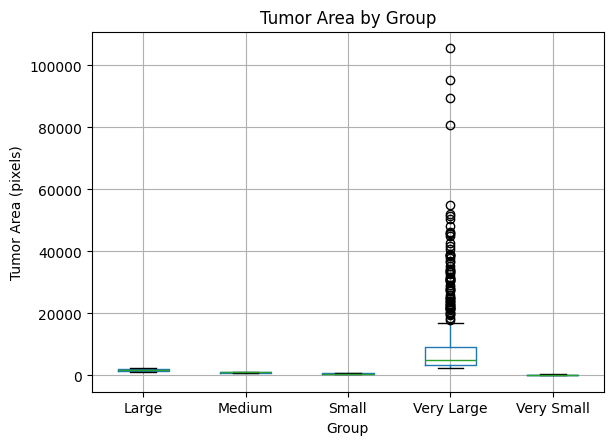

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
group_df.boxplot(column="Tumor Area", by="Group")
plt.suptitle("")
plt.title("Tumor Area by Group")
plt.ylabel("Tumor Area (pixels)")
plt.show()

In [61]:
import os

os.makedirs("tumor_groups", exist_ok=True)

np.save("tumor_groups/X_vs.npy", X_vs)
np.save("tumor_groups/Y_vs.npy", Y_vs)

np.save("tumor_groups/X_s.npy", X_s)
np.save("tumor_groups/Y_s.npy", Y_s)

np.save("tumor_groups/X_m.npy", X_m)
np.save("tumor_groups/Y_m.npy", Y_m)

np.save("tumor_groups/X_l.npy", X_l)
np.save("tumor_groups/Y_l.npy", Y_l)

np.save("tumor_groups/X_vl.npy", X_vl)
np.save("tumor_groups/Y_vl.npy", Y_vl)

print("All groups saved successfully!")

All groups saved successfully!


In [62]:
import os

for file in sorted(os.listdir("tumor_groups")):
    arr = np.load(os.path.join("tumor_groups", file))
    print(file, arr.shape)

X_l.npy (648, 224, 224)
X_m.npy (648, 224, 224)
X_s.npy (646, 224, 224)
X_vl.npy (649, 224, 224)
X_vs.npy (651, 224, 224)
Y_l.npy (648, 224, 224)
Y_m.npy (648, 224, 224)
Y_s.npy (646, 224, 224)
Y_vl.npy (649, 224, 224)
Y_vs.npy (651, 224, 224)


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_temp, Y_train, Y_temp, label_train, label_temp = train_test_split(
    X,
    Y,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

X_val, X_test, Y_val, Y_test, label_val, label_test = train_test_split(
    X_temp,
    Y_temp,
    label_temp,
    test_size=0.50,
    random_state=42,
    stratify=label_temp
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(2593, 224, 224)
(324, 224, 224)
(325, 224, 224)


In [64]:
import os
import numpy as np

os.makedirs("tumor_split", exist_ok=True)

np.save("tumor_split/X_train.npy", X_train)
np.save("tumor_split/Y_train.npy", Y_train)

np.save("tumor_split/X_val.npy", X_val)
np.save("tumor_split/Y_val.npy", Y_val)

np.save("tumor_split/X_test.npy", X_test)
np.save("tumor_split/Y_test.npy", Y_test)

np.save("tumor_split/label_train.npy", label_train)
np.save("tumor_split/label_val.npy", label_val)
np.save("tumor_split/label_test.npy", label_test)

print("Saved Successfully!")

Saved Successfully!


In [65]:
import os

for file in sorted(os.listdir("tumor_split")):
    arr = np.load(os.path.join("tumor_split", file), allow_pickle=True)
    print(file, arr.shape)

X_test.npy (325, 224, 224)
X_train.npy (2593, 224, 224)
X_val.npy (324, 224, 224)
Y_test.npy (325, 224, 224)
Y_train.npy (2593, 224, 224)
Y_val.npy (324, 224, 224)
label_test.npy (325,)
label_train.npy (2593,)
label_val.npy (324,)


In [66]:
import numpy as np

X_train = np.load("tumor_split/X_train.npy")
Y_train = np.load("tumor_split/Y_train.npy")

X_val = np.load("tumor_split/X_val.npy")
Y_val = np.load("tumor_split/Y_val.npy")

X_test = np.load("tumor_split/X_test.npy")
Y_test = np.load("tumor_split/Y_test.npy")

label_test = np.load("tumor_split/label_test.npy")

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(2593, 224, 224)
(324, 224, 224)
(325, 224, 224)


In [67]:
X_train = np.expand_dims(X_train, axis=1)
X_val   = np.expand_dims(X_val, axis=1)
X_test  = np.expand_dims(X_test, axis=1)

Y_train = np.expand_dims(Y_train, axis=1)
Y_val   = np.expand_dims(Y_val, axis=1)
Y_test  = np.expand_dims(Y_test, axis=1)

print(X_train.shape)

(2593, 1, 224, 224)


In [68]:
import torch
from torch.utils.data import Dataset

class BreastDataset(Dataset):
    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx], dtype=torch.float32)
        mask = torch.tensor(self.masks[idx], dtype=torch.float32)
        return image, mask

In [69]:
train_dataset = BreastDataset(X_train, Y_train)
val_dataset   = BreastDataset(X_val, Y_val)
test_dataset  = BreastDataset(X_test, Y_test)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

2593
324
325


In [70]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [71]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

torch.Size([16, 1, 224, 224])
torch.Size([16, 1, 224, 224])


In [72]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [73]:
import torch
import torch.nn as nn

# ---------------- Double Conv ----------------
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


# ---------------- Attention Block ----------------
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi


# ---------------- Attention U-Net ----------------
class AttentionUNet(nn.Module):

    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        self.pool = nn.MaxPool2d(2)

        self.c1 = DoubleConv(in_channels,64)
        self.c2 = DoubleConv(64,128)
        self.c3 = DoubleConv(128,256)
        self.c4 = DoubleConv(256,512)

        self.bridge = DoubleConv(512,1024)

        self.up4 = nn.ConvTranspose2d(1024,512,2,stride=2)
        self.att4 = AttentionBlock(512,512,256)
        self.dec4 = DoubleConv(1024,512)

        self.up3 = nn.ConvTranspose2d(512,256,2,stride=2)
        self.att3 = AttentionBlock(256,256,128)
        self.dec3 = DoubleConv(512,256)

        self.up2 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.att2 = AttentionBlock(128,128,64)
        self.dec2 = DoubleConv(256,128)

        self.up1 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.att1 = AttentionBlock(64,64,32)
        self.dec1 = DoubleConv(128,64)

        self.final = nn.Conv2d(64,out_channels,1)

    def forward(self,x):

        c1 = self.c1(x)
        p1 = self.pool(c1)

        c2 = self.c2(p1)
        p2 = self.pool(c2)

        c3 = self.c3(p2)
        p3 = self.pool(c3)

        c4 = self.c4(p3)
        p4 = self.pool(c4)

        bridge = self.bridge(p4)

        d4 = self.up4(bridge)
        c4 = self.att4(d4,c4)
        d4 = torch.cat([d4,c4],dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        c3 = self.att3(d3,c3)
        d3 = torch.cat([d3,c3],dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        c2 = self.att2(d2,c2)
        d2 = torch.cat([d2,c2],dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        c1 = self.att1(d1,c1)
        d1 = torch.cat([d1,c1],dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [74]:
model = AttentionUNet(
    in_channels=1,
    out_channels=1
).to(device)

In [75]:
import torch
import torch.nn as nn

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)

        pred = pred.view(-1)
        target = target.view(-1)

        intersection = (pred * target).sum()

        dice = (2 * intersection + self.smooth) / (
            pred.sum() + target.sum() + self.smooth
        )

        return 1 - dice


class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, pred, target):
        bce = self.bce(pred, target)
        dice = self.dice(pred, target)

        return 0.5 * bce + 0.5 * dice

In [76]:
import torch.optim as optim

criterion = BCEDiceLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

scaler = torch.amp.GradScaler("cuda")

In [77]:
def dice_score(pred, target, smooth=1e-6):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))

    dice = (2 * intersection + smooth) / (union + smooth)

    return dice.mean()

In [78]:
def iou_score(pred, target, smooth=1e-6):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - intersection

    iou = (intersection + smooth) / (union + smooth)

    return iou.mean()

In [79]:
scaler = torch.amp.GradScaler("cuda")

In [80]:
import torch

def segmentation_metrics(pred, target, smooth=1e-6):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    target = target.float()

    TP = (pred * target).sum(dim=(1,2,3))
    FP = (pred * (1 - target)).sum(dim=(1,2,3))
    FN = ((1 - pred) * target).sum(dim=(1,2,3))

    # Dice
    dice = (2 * TP + smooth) / (2 * TP + FP + FN + smooth)

    # IoU
    iou = (TP + smooth) / (TP + FP + FN + smooth)

    # Precision
    precision = (TP + smooth) / (TP + FP + smooth)

    # Recall
    recall = (TP + smooth) / (TP + FN + smooth)

    # F1 Score
    f1 = (2 * precision * recall + smooth) / (precision + recall + smooth)

    return (
        dice.mean().item(),
        iou.mean().item(),
        precision.mean().item(),
        recall.mean().item(),
        f1.mean().item()
    )

In [81]:
history = {
    "train_loss": [],
    "val_loss": [],

    "train_dice": [],
    "val_dice": [],

    "train_iou": [],
    "val_iou": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_f1": [],
    "val_f1": []
}

In [82]:
from tqdm import tqdm
import torch
import os

# ==========================
# Training Configuration
# ==========================

num_epochs = 50

best_val_dice = 0.0
patience = 10
counter = 0

os.makedirs("checkpoints", exist_ok=True)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

# ==========================
# Training
# ==========================

for epoch in range(num_epochs):

    ##############################
    # TRAIN
    ##############################

    model.train()

    train_loss = 0

    train_dice = 0
    train_iou = 0
    train_precision = 0
    train_recall = 0
    train_f1 = 0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):

            outputs = model(images)

            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        train_loss += loss.item()

        dice, iou, precision, recall, f1 = segmentation_metrics(outputs, masks)

        train_dice += dice
        train_iou += iou
        train_precision += precision
        train_recall += recall
        train_f1 += f1

    train_loss /= len(train_loader)
    train_dice /= len(train_loader)
    train_iou /= len(train_loader)
    train_precision /= len(train_loader)
    train_recall /= len(train_loader)
    train_f1 /= len(train_loader)

    ##############################
    # VALIDATION
    ##############################

    model.eval()

    val_loss = 0

    val_dice = 0
    val_iou = 0
    val_precision = 0
    val_recall = 0
    val_f1 = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            val_loss += loss.item()

            dice, iou, precision, recall, f1 = segmentation_metrics(outputs, masks)

            val_dice += dice
            val_iou += iou
            val_precision += precision
            val_recall += recall
            val_f1 += f1

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou /= len(val_loader)
    val_precision /= len(val_loader)
    val_recall /= len(val_loader)
    val_f1 /= len(val_loader)

    ##############################
    # Scheduler
    ##############################

    scheduler.step(val_dice)

    ##############################
    # Save History
    ##############################

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    history["train_precision"].append(train_precision)
    history["val_precision"].append(val_precision)

    history["train_recall"].append(train_recall)
    history["val_recall"].append(val_recall)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    ##############################
    # Print Metrics
    ##############################

    print("\n" + "="*70)
    print(f"Epoch [{epoch+1}/{num_epochs}]")

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Train Dice : {train_dice:.4f}")
    print(f"Val Dice   : {val_dice:.4f}")

    print(f"Train IoU  : {train_iou:.4f}")
    print(f"Val IoU    : {val_iou:.4f}")

    print(f"Train Precision : {train_precision:.4f}")
    print(f"Val Precision   : {val_precision:.4f}")

    print(f"Train Recall : {train_recall:.4f}")
    print(f"Val Recall   : {val_recall:.4f}")

    print(f"Train F1 : {train_f1:.4f}")
    print(f"Val F1   : {val_f1:.4f}")

    print(f"Learning Rate : {optimizer.param_groups[0]['lr']:.6f}")

    ##############################
    # Save Best Model
    ##############################

    if val_dice > best_val_dice:

        best_val_dice = val_dice
        counter = 0

        torch.save(
            model.state_dict(),
            "checkpoints/best_attention_unet.pth"
        )

        print("✅ Best model saved.")

    else:

        counter += 1

        print(f"No improvement. EarlyStopping Counter: {counter}/{patience}")

    ##############################
    # Early Stopping
    ##############################

    if counter >= patience:

        print("\n🛑 Early Stopping Triggered.")
        print(f"Best Validation Dice : {best_val_dice:.4f}")

        break

print("\nTraining Finished.")
print(f"Best Validation Dice : {best_val_dice:.4f}")

Epoch 1/50: 100%|██████████| 163/163 [00:56<00:00,  2.91it/s]



Epoch [1/50]
Train Loss : 0.5390
Val Loss   : 0.4835
Train Dice : 0.5987
Val Dice   : 0.6362
Train IoU  : 0.4658
Val IoU    : 0.4969
Train Precision : 0.5337
Val Precision   : 0.5227
Train Recall : 0.8456
Val Recall   : 0.9233
Train F1 : 0.6042
Val F1   : 0.6391
Learning Rate : 0.000100
✅ Best model saved.


Epoch 2/50: 100%|██████████| 163/163 [00:55<00:00,  2.92it/s]



Epoch [2/50]
Train Loss : 0.4325
Val Loss   : 0.4492
Train Dice : 0.6928
Val Dice   : 0.6362
Train IoU  : 0.5617
Val IoU    : 0.4903
Train Precision : 0.6431
Val Precision   : 0.5068
Train Recall : 0.8721
Val Recall   : 0.9463
Train F1 : 0.6981
Val F1   : 0.6362
Learning Rate : 0.000100
✅ Best model saved.


Epoch 3/50: 100%|██████████| 163/163 [00:57<00:00,  2.84it/s]


...


Epoch [48/50]
Train Loss : 0.0769
Val Loss   : 0.1600
Train Dice : 0.8790
Val Dice   : 0.7695
Train IoU  : 0.7959
Val IoU    : 0.6553
Train Precision : 0.8844
Val Precision   : 0.8670
Train Recall : 0.8917
Val Recall   : 0.7292
Train F1 : 0.8801
Val F1   : 0.7753
Learning Rate : 0.000002
No improvement. EarlyStopping Counter: 8/10


Epoch 49/50: 100%|██████████| 163/163 [00:59<00:00,  2.74it/s]



Epoch [49/50]
Train Loss : 0.0751
Val Loss   : 0.1516
Train Dice : 0.8801
Val Dice   : 0.7921
Train IoU  : 0.7968
Val IoU    : 0.6841
Train Precision : 0.8840
Val Precision   : 0.8368
Train Recall : 0.8926
Val Recall   : 0.7855
Train F1 : 0.8818
Val F1   : 0.7980
Learning Rate : 0.000002
No improvement. EarlyStopping Counter: 9/10


Epoch 50/50: 100%|██████████| 163/163 [00:59<00:00,  2.74it/s]



Epoch [50/50]
Train Loss : 0.0739
Val Loss   : 0.1507
Train Dice : 0.8812
Val Dice   : 0.7998
Train IoU  : 0.7987
Val IoU    : 0.6911
Train Precision : 0.8842
Val Precision   : 0.8405
Train Recall : 0.8950
Val Recall   : 0.7920
Train F1 : 0.8824
Val F1   : 0.8027
Learning Rate : 0.000002
No improvement. EarlyStopping Counter: 10/10

🛑 Early Stopping Triggered.
Best Validation Dice : 0.8134

Training Finished.
Best Validation Dice : 0.8134


In [83]:
model = AttentionUNet(in_channels=1, out_channels=1).to(device)

model.load_state_dict(
    torch.load(
        "checkpoints/best_attention_unet.pth",
        map_location=device
    )
)

model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [84]:
test_loss = 0

test_dice = 0
test_iou = 0
test_precision = 0
test_recall = 0
test_f1 = 0

model.eval()

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        test_loss += loss.item()

        dice, iou, precision, recall, f1 = segmentation_metrics(outputs, masks)

        test_dice += dice
        test_iou += iou
        test_precision += precision
        test_recall += recall
        test_f1 += f1

test_loss /= len(test_loader)
test_dice /= len(test_loader)
test_iou /= len(test_loader)
test_precision /= len(test_loader)
test_recall /= len(test_loader)
test_f1 /= len(test_loader)

print("="*60)
print("TEST RESULTS")
print("="*60)

print(f"Loss      : {test_loss:.4f}")
print(f"Dice      : {test_dice:.4f}")
print(f"IoU       : {test_iou:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")

TEST RESULTS
Loss      : 0.1366
Dice      : 0.8304
IoU       : 0.7225
Precision : 0.8150
Recall    : 0.8709
F1 Score  : 0.8304


In [85]:
import pandas as pd

results = pd.DataFrame({

    "Dataset": ["Train", "Validation", "Test"],

    "Loss": [
        history["train_loss"][-1],
        history["val_loss"][-1],
        test_loss
    ],

    "Dice": [
        history["train_dice"][-1],
        history["val_dice"][-1],
        test_dice
    ],

    "IoU": [
        history["train_iou"][-1],
        history["val_iou"][-1],
        test_iou
    ],

    "Precision": [
        history["train_precision"][-1],
        history["val_precision"][-1],
        test_precision
    ],

    "Recall": [
        history["train_recall"][-1],
        history["val_recall"][-1],
        test_recall
    ],

    "F1": [
        history["train_f1"][-1],
        history["val_f1"][-1],
        test_f1
    ]
})

results

,Dataset,Loss,Dice,IoU,Precision,Recall,F1
0,Train,0.073880,0.881173,0.798657,0.884200,0.895032,0.882360
1,Validation,0.150701,0.799801,0.691132,0.840455,0.791982,0.802731
2,Test,0.136647,0.830444,0.722502,0.815024,0.870928,0.830444


In [87]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [90]:
import numpy as np

X_vs = np.load("tumor_groups/X_vs.npy")
Y_vs = np.load("tumor_groups/Y_vs.npy")

X_s = np.load("tumor_groups/X_s.npy")
Y_s = np.load("tumor_groups/Y_s.npy")

X_m = np.load("tumor_groups/X_m.npy")
Y_m = np.load("tumor_groups/Y_m.npy")

X_l = np.load("tumor_groups/X_l.npy")
Y_l = np.load("tumor_groups/Y_l.npy")

X_vl = np.load("tumor_groups/X_vl.npy")
Y_vl = np.load("tumor_groups/Y_vl.npy")

In [91]:
from torch.utils.data import Dataset

class BreastDataset(Dataset):

    def __init__(self, X, Y):

        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.Y = torch.tensor(Y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [92]:
from torch.utils.data import DataLoader
import pandas as pd

def evaluate_group(X, Y):

    dataset = BreastDataset(X, Y)

    loader = DataLoader(
        dataset,
        batch_size=16,
        shuffle=False
    )

    loss = 0
    dice = 0
    iou = 0
    precision = 0
    recall = 0
    f1 = 0

    model.eval()

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            l = criterion(outputs, masks)

            loss += l.item()

            d, i, p, r, f = segmentation_metrics(outputs, masks)

            dice += d
            iou += i
            precision += p
            recall += r
            f1 += f

    n = len(loader)

    return [
        loss/n,
        dice/n,
        iou/n,
        precision/n,
        recall/n,
        f1/n
    ]

In [93]:
results = []

groups = [
    ("Very Small", X_vs, Y_vs),
    ("Small", X_s, Y_s),
    ("Medium", X_m, Y_m),
    ("Large", X_l, Y_l),
    ("Very Large", X_vl, Y_vl)
]

for name, X, Y in groups:

    metrics = evaluate_group(X, Y)

    results.append([name] + metrics)

In [94]:
import pandas as pd

tumor_results = pd.DataFrame(

    results,

    columns=[
        "Tumor Group",
        "Loss",
        "Dice",
        "IoU",
        "Precision",
        "Recall",
        "F1"
    ]
)

tumor_results

,Tumor Group,Loss,Dice,IoU,Precision,Recall,F1
0,Very Small,0.126690,0.788577,0.675435,0.788350,0.834892,0.796696
1,Small,0.090855,0.878443,0.788076,0.871489,0.894675,0.878443
2,Medium,0.085045,0.895322,0.814783,0.884072,0.912335,0.895322
3,Large,0.090790,0.898680,0.823109,0.889484,0.915543,0.898680
4,Very Large,0.107686,0.901356,0.831652,0.891167,0.922633,0.901356
